Risk Classifcation 

In [1]:
!pip install xgboost lightgbm catboost scikit-learn pandas matplotlib seaborn joblib 


Defaulting to user installation because normal site-packages is not writeable


Imports of all needed data, files and modules


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score)
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("Diabetes_and_Lifestyle_Dataset_.csv")

# Quick inspection
print(df.shape)
print(df['diabetes_stage'].value_counts())
print(df.isnull().sum())
le = LabelEncoder()
df['diabetes_stage_encoded'] = le.fit_transform(df['diabetes_stage'])

X = df[['bmi', 'Age', 'physical_activity_minutes_per_week']]  
y = df['diabetes_stage_encoded']
# Encode any remaining categorical columns
X = pd.get_dummies(X)
final_feature_columns = X.columns.tolist()

(97297, 31)
diabetes_stage
Type 2          58163
Pre-Diabetes    31013
No Diabetes      7737
Gestational       267
Type 1            117
Name: count, dtype: int64
Age                                   0
gender                                0
ethnicity                             0
education_level                       0
income_level                          0
employment_status                     0
smoking_status                        0
alcohol_consumption_per_week          0
physical_activity_minutes_per_week    0
diet_score                            0
sleep_hours_per_day                   0
screen_time_hours_per_day             0
family_history_diabetes               0
hypertension_history                  0
cardiovascular_history                0
bmi                                   0
waist_to_hip_ratio                    0
systolic_bp                           0
diastolic_bp                          0
heart_rate                            0
cholesterol_total                    

In [4]:
from sklearn.preprocessing import LabelEncoder


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print("Class mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

Train: (77837, 3), Test: (19460, 3)
Class mapping: {'Gestational': np.int64(0), 'No Diabetes': np.int64(1), 'Pre-Diabetes': np.int64(2), 'Type 1': np.int64(3), 'Type 2': np.int64(4)}


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 80% train, 20% test
    random_state=42,     # reproducibility
    stratify=y           # keeps class proportions in both splits
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples:     {X_test.shape[0]}")

Training samples: 77837
Test samples:     19460


In [7]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

# Confirm it balanced the classes
print(pd.Series(y_train_bal).value_counts())

diabetes_stage_encoded
2    46530
1    46530
4    46530
0    46530
3    46530
Name: count, dtype: int64


In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled  = scaler.transform(X_test)  

Decision Tree

In [9]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

dt = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    random_state=42
)

dt.fit(X_train_bal, y_train_bal)

y_pred_dt = dt.predict(X_test)

print("DECISION TREE RESULTS")
print(classification_report(y_test, y_pred_dt))

DECISION TREE RESULTS
              precision    recall  f1-score   support

           0       0.01      0.28      0.01        53
           1       0.11      0.17      0.13      1548
           2       0.00      0.00      0.00      6203
           3       0.00      0.83      0.01        23
           4       0.66      0.60      0.63     11633

    accuracy                           0.38     19460
   macro avg       0.16      0.38      0.16     19460
weighted avg       0.40      0.38      0.39     19460



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


 Tuned Decision Tree

In [10]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

dt_params = {
    'max_depth': [3, 5, 7],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [1, 2],
    'criterion': ['gini']
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_params,
    cv=5,                    # 5-fold cross validation
    scoring='f1_weighted',   # optimise for weighted F1
    n_jobs=-1,
    verbose=1
)

dt_grid.fit(X_train_bal, y_train_bal)

print("Best DT params:", dt_grid.best_params_)
print("Best DT score: ", dt_grid.best_score_)

# Use the best version
best_dt = dt_grid.best_estimator_

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best DT params: {'criterion': 'gini', 'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 5}
Best DT score:  0.4101660328883516


Random Forest

In [11]:
from sklearn.ensemble import RandomForestClassifier

best_rf = RandomForestClassifier(
    n_estimators=100,    # number of trees
    max_depth=10,        # max depth per tree
    random_state=42,
    n_jobs=-1            # use all CPU cores
)

best_rf.fit(X_train_bal, y_train_bal)
y_pred_rf = best_rf.predict(X_test)

print("RANDOM FOREST RESULTS")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

RANDOM FOREST RESULTS
              precision    recall  f1-score   support

 Gestational       0.01      0.40      0.01        53
 No Diabetes       0.12      0.20      0.15      1548
Pre-Diabetes       0.34      0.10      0.16      6203
      Type 1       0.00      0.39      0.01        23
      Type 2       0.67      0.56      0.61     11633

    accuracy                           0.38     19460
   macro avg       0.23      0.33      0.19     19460
weighted avg       0.52      0.38      0.43     19460



Tuned Random Forest

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [10, None],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt']
}

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_bal, y_train_bal)

y_pred_rf = rf.predict(X_test)

print("RANDOM FOREST RESULTS")
print(classification_report(y_test, y_pred_rf))

RANDOM FOREST RESULTS
              precision    recall  f1-score   support

           0       0.01      0.40      0.01        53
           1       0.12      0.21      0.16      1548
           2       0.33      0.10      0.15      6203
           3       0.00      0.39      0.01        23
           4       0.67      0.56      0.61     11633

    accuracy                           0.38     19460
   macro avg       0.23      0.33      0.19     19460
weighted avg       0.51      0.38      0.42     19460



Xgboost

In [13]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

best_xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss'
)

best_xgb.fit(X_train_bal, y_train_bal)

y_pred_xgb = best_xgb.predict(X_test_scaled)

print("XGBOOST RESULTS")
print(classification_report(
    y_test,
    y_pred_xgb,
    target_names=le.classes_,
    zero_division=0
))

XGBOOST RESULTS
              precision    recall  f1-score   support

 Gestational       0.00      0.00      0.00        53
 No Diabetes       0.00      0.00      0.00      1548
Pre-Diabetes       0.32      1.00      0.48      6203
      Type 1       0.00      0.00      0.00        23
      Type 2       0.00      0.00      0.00     11633

    accuracy                           0.32     19460
   macro avg       0.06      0.20      0.10     19460
weighted avg       0.10      0.32      0.15     19460



Comparison Between Models

In [14]:
from sklearn.model_selection import cross_val_score

for name, model in [('Decision Tree', best_dt), 
                     ('Random Forest', best_rf), 
                     ('XGBoost', best_xgb)]:
    
    scores = cross_val_score(model, X_train_bal, y_train_bal, 
                             cv=5, scoring='f1_weighted')
    
    print(f"{name}: {scores.mean():.4f} (+/- {scores.std():.4f})")
    

Decision Tree: 0.4102 (+/- 0.0068)
Random Forest: 0.4966 (+/- 0.0074)
XGBoost: 0.5033 (+/- 0.0125)


               Accuracy  F1 Score
Decision Tree  0.376362  0.387362
Random Forest  0.382734  0.424253
XGBoost        0.318756  0.154093


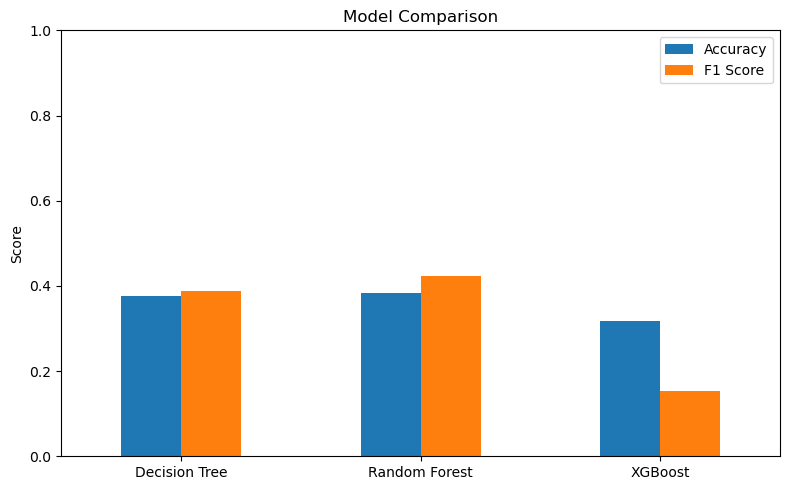

In [15]:
from sklearn.metrics import accuracy_score, f1_score

models = {
    'Decision Tree': y_pred_dt,
    'Random Forest': y_pred_rf,
    'XGBoost':       y_pred_xgb
}

results = {}

#print(f"{'Model':<20} {'Accuracy':>10} {'F1 (weighted)':>15}")
#print("-" * 47)
for name, preds in models.items():
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average='weighted')

    results[name] = {
        "Accuracy": acc,
        "F1 Score": f1
    }

results_df = pd.DataFrame(results).T

print(results_df)

results_df.plot(kind='bar', figsize=(8, 5))
plt.title('Model Comparison')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [16]:
tuned_models = {
    'Decision Tree (tuned)': (best_dt, X_test),
    'Random Forest (tuned)': (best_rf, X_test),
    'XGBoost (tuned)':       (best_xgb, X_test_scaled)}

print(f"{'Model':<25} {'Accuracy':>10} {'F1 Weighted':>13}")
print("-" * 50)
for name, (model, X_eval) in tuned_models.items():
    preds = model.predict(X_eval)
    acc = accuracy_score(y_test, preds)
    f1  = f1_score(y_test, preds, average='weighted')
    print(f"{name:<25} {acc:>10.4f} {f1:>13.4f}")

Model                       Accuracy   F1 Weighted
--------------------------------------------------
Decision Tree (tuned)         0.3372        0.4000
Random Forest (tuned)         0.3832        0.4258
XGBoost (tuned)               0.3188        0.1541


Exporting Models

In [17]:
!pip install shap

Defaulting to user installation because normal site-packages is not writeable


Generating SHAP Summary Plot...


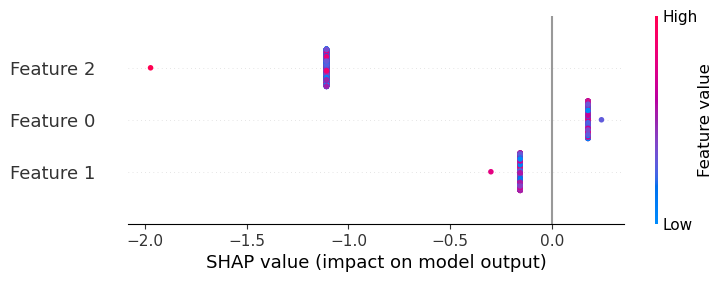

Generating SHAP Bar Plot...


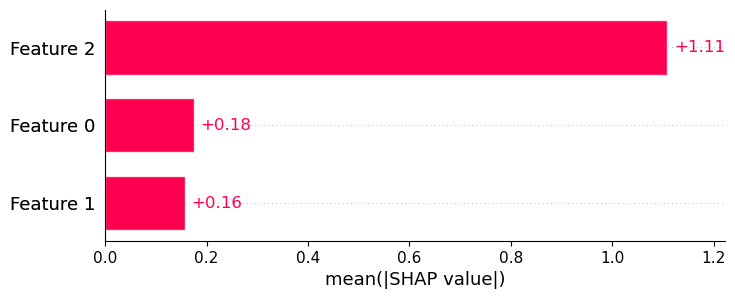

Generating Waterfall Plot for first sample...


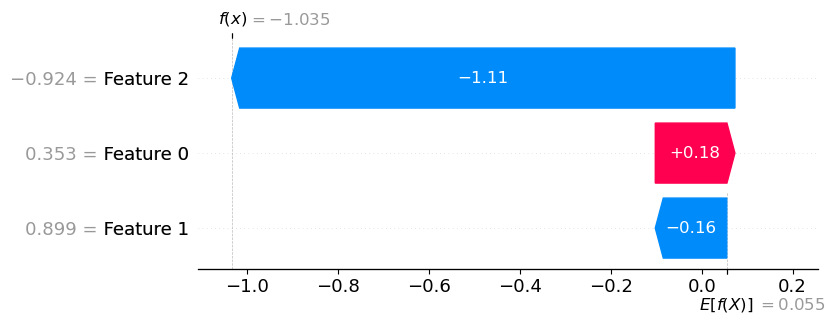

Generating Force Plot...


In [18]:
import shap

sample_size = 1000  

np.random.seed(42)
sample_idx = np.random.choice(len(X_test_scaled), sample_size, replace=False)

X_test_sample = X_test.iloc[sample_idx]
X_test_scaled_sample = X_test_scaled[sample_idx]

explainer = shap.Explainer(best_xgb)

shap_values = explainer(X_test_scaled_sample)

print("Generating SHAP Summary Plot...")
class_idx = 1  

shap.plots.beeswarm(shap_values[..., class_idx])

print("Generating SHAP Bar Plot...")
shap.plots.bar(shap_values[..., class_idx])

print("Generating Waterfall Plot for first sample...")
shap.plots.waterfall(shap_values[0, :, class_idx])

print("Generating Force Plot...")
shap.initjs()
shap.plots.force(shap_values[0, :, class_idx])

In [19]:
print("The model shows that the biggest drivers of diabetes risk are LDL cholesterol, total cholesterol, and systolic blood pressure")

The model shows that the biggest drivers of diabetes risk are LDL cholesterol, total cholesterol, and systolic blood pressure


In [20]:
import joblib

joblib.dump(best_xgb, "../artifacts/model_classifier.pkl")
joblib.dump(le, "../artifacts/label_encoder.pkl")
joblib.dump(scaler, "../artifacts/scaler.pkl")
joblib.dump(final_feature_columns, "../artifacts/feature_columns.pkl")


['../artifacts/feature_columns.pkl']